# Structural alignment for pathogenicity hotbed identificaton

Strucutures of analyzed GLUT files has been structuraly aligned using DALI server. This workflow uses the obtained alignment to identiify hotbeds of pathogenicity in relation of the aminoacid residues to the membrane in the GLUT family. Pathogenicity prediction is taken from AlphaMissense results for whole proteins.

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

load the files form `data/align`

we focused on the alignment to the GLUT13 as it is longest sequence

In [2]:
struct_al_f = Path.cwd() / 'data/align/s013A.dali.tsv'
struct_al = pd.read_csv(struct_al_f,sep='\t')

retype text to numeric

In [3]:
def strlist2intlist(strlist,bracketed=True):
    if bracketed:
        strlist = strlist[1:-1]
    strlist = strlist.split()
    intlist = []
    for s in strlist:
        intlist.append(int(s))
    return intlist
    

In [4]:
struct_al['qstarts'] = struct_al['qstarts'].apply(strlist2intlist)
struct_al['sstarts'] = struct_al['sstarts'].apply(strlist2intlist)
struct_al['lengths'] = struct_al['lengths'].apply(strlist2intlist)

In [5]:
proteins = {
    'GLUT1':'P11166',
    'GLUT2':'P11168',
    'GLUT3':'P11169',
    'GLUT4':'P14672',
    'GLUT5':'P22732',
    'GLUT6':'Q9UGQ3',
    'GLUT7':'Q6PXP3',
    'GLUT8':'Q9NY64',
    'GLUT9':'Q9NRM0',
    'GLUT10':'O95528',
    'GLUT11':'Q9BYW1',
    'GLUT12':'Q8TD20',
    'GLUT13':'Q96QE2',
    'GLUT14':'Q8TDB8' 
    }

obtain pathogeicity data for whole proteins

In [6]:
PATO_DIR = Path.cwd() / 'results/pathogenicities/alphamissense'

In [7]:
pato_align = pd.read_csv(PATO_DIR / f'all_{proteins["GLUT13"]}.csv')

In [8]:
pato_align = pato_align.drop('residue_name', axis=1)
pato_align = pato_align.rename(columns={'residue_label':'GLUT13', 'pathogenicity': 'p13'})

mapping of possition and their pathogenicites to each other to get average pathogenicity per possition

In [9]:
def AA_mapping(qstarts, sstarts, lenghts, q_length = 648):
    mapped = []
    for i in range(len(qstarts)):
        mapped_len = len(mapped)
        n_nan = qstarts[i] - (mapped_len+1)
        mapped = mapped + [np.nan]*n_nan
        mapped = mapped + list(range(sstarts[i],sstarts[i]+lenghts[i]))
    missing = q_length - len(mapped)
    mapped = mapped + [np.nan]*missing
    return mapped

In [10]:
for index, row in struct_al.iterrows():
    n = str(int(row['sbjct'][1:-1]))
    if n == '13':
        continue
    mapping = AA_mapping(row['qstarts'],row['sstarts'],row['lengths'])
    pato_align[f'GLUT{n}'] = mapping

In [11]:
for i in range(1,15):
    if i == 13:
        continue
    glut = f'GLUT{str(i)}'
    pato_f = PATO_DIR / f'all_{proteins[glut]}.csv'
    pato_df = pd.read_csv(pato_f,index_col='residue_label')
    pats = []
    for index, row in pato_align.iterrows():
        if np.isnan(row[glut]):
            pats.append(np.nan)
        else:
            pats.append(pato_df.loc[int(row[glut])]['pathogenicity'])
    pato_align[f'p{str(i)}'] = pats

In [12]:
avg_list = []
missing_list = []
for index, row in pato_align.iterrows():
    pato_sum = 0
    miss_count = 0
    for i in range(1,15):
        p = row[f'p{i}']
        if np.isnan(p):
            miss_count += 1
        else:
            pato_sum += p
    avg_list.append(pato_sum/(14-miss_count)) 
    missing_list.append(miss_count)
pato_align['avg_p'] = avg_list
pato_align['missing'] = missing_list

Identification of intramembrane regions for later highlight from DeepTMHMM predictions.

In [13]:
TOPO_DIR = Path.cwd() / 'results/deeptmhmm'
topo_file = TOPO_DIR / f'{proteins["GLUT13"]}.3line'

In [14]:
topo_f = open(topo_file, "r")
topology = topo_f.read().splitlines()[2]
pato_align['topology'] = list(topology)
topo_f.close()

In [15]:
pato_align.iloc[34:54][['GLUT13','GLUT9','p9','missing','avg_p','topology']]

,GLUT13,GLUT9,p9,missing,avg_p,topology
34,35,NaN,NaN,13,0.130000,I
35,36,1.0,0.12,12,0.130000,I
36,37,2.0,0.14,12,0.205000,I
37,38,3.0,0.16,12,0.265000,I
38,39,4.0,0.19,12,0.165000,I
39,40,5.0,0.15,12,0.240000,I
40,41,6.0,0.12,12,0.195000,I
41,42,7.0,0.12,12,0.170000,I
42,43,8.0,0.12,12,0.170000,I
43,44,9.0,0.12,11,0.160000,I


Plotting part. Intramembrane regions are highlighted in green.

In [16]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [17]:
def colored_line_between_pts(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified between (x, y) points by a third value.

    It does this by creating a collection of line segments between each pair of
    neighboring points. The color of each segment is determined by the
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should have a size one less than that of x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Check color array size (LineCollection still works, but values are unused)
    if len(c) != len(x) - 1:
        warnings.warn(
            "The c argument should have a length one less than the length of x and y. "
            "If it has the same length, use the colored_line function instead."
        )

    # Create a set of line segments so that we can color them individually
    # This creates the points as an N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, **lc_kwargs)

    # Set the values used for colormapping
    lc.set_array(c)

    return ax.add_collection(lc)

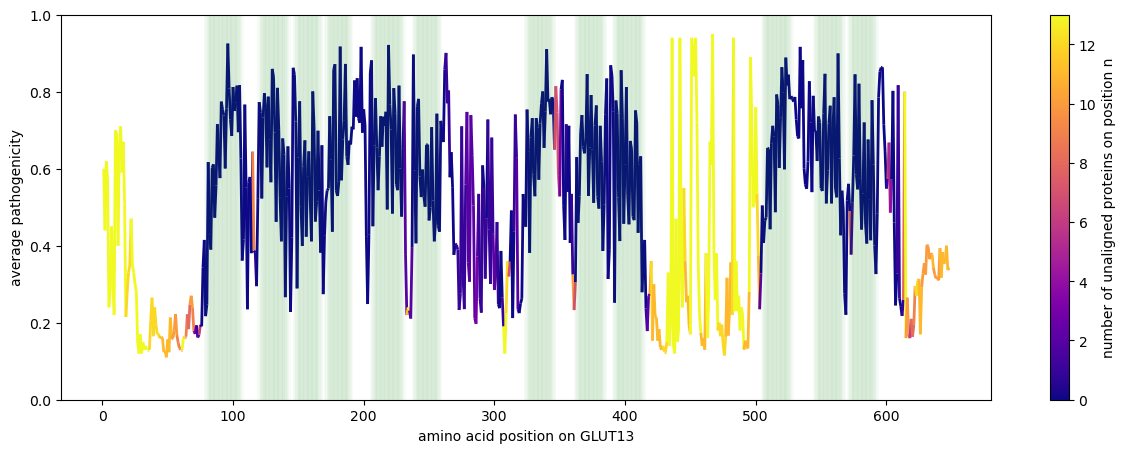

In [18]:
x = pato_align['GLUT13']
y = pato_align['avg_p']
missing = pato_align['missing'][:-1]

fig, ax = plt.subplots(figsize=(15, 5))
line = colored_line_between_pts(x, y, missing, ax, linewidth=2, cmap="plasma")
fig.colorbar(line, ax=ax, label="number of unaligned proteins on position n")
#ax.set_xlim(x.min(), x.max())


intracellurar = pato_align[pato_align['topology']== 'I'].index 
membrane = pato_align[pato_align['topology']== 'M'].index
extracellular = pato_align[pato_align['topology']== 'O'].index

plt.xlabel('amino acid position on GLUT13')
plt.ylabel('average pathogenicity')
#for x in zeros:
#    ax.axvline(pato_align.index[x], color='y',linewidth=5,alpha=0.03)
for x in membrane:
     ax.axvline(pato_align.index[x], color='g',linewidth=5,alpha=0.03)
#for x in neg_1:
#     ax.axvline(pato_align.index[x], color='r',linewidth=5,alpha=0.03)
plt.savefig(Path.cwd() / 'results/pathogenicity_alignment_GLUT13.tiff',format='tiff', dpi=300)
plt.show()

# GLUT1 mapping

same process has been repeated for alignment of GLUT1 protein.

In [19]:
struct_al_f = Path.cwd() / 'data/align/s001A.dali.tsv'
struct_al = pd.read_csv(struct_al_f,sep='\t')

In [20]:
struct_al['qstarts'] = struct_al['qstarts'].apply(strlist2intlist)
struct_al['sstarts'] = struct_al['sstarts'].apply(strlist2intlist)
struct_al['lengths'] = struct_al['lengths'].apply(strlist2intlist)

In [21]:
pato_align = pd.read_csv(PATO_DIR / f'all_{proteins["GLUT1"]}.csv')

In [22]:
pato_align = pato_align.drop('residue_name', axis=1)
pato_align = pato_align.rename(columns={'residue_label':'GLUT1', 'pathogenicity': 'p1'})

In [23]:
struct_al.head()

,query,database,sbjct,z-score,rmsd,ali-length,sbjct-length,seq-identity,sbjct-sequence,sbjct-dssp,description,qstarts,sstarts,lengths,rotation,translation
0,s001A,Query,s001A,.,0.0,492,492,100,MEPSSKKLTGRLMLAVGGAVLGSLQFGYNTGVINAPQKVIEEFYNQ...,LLLHHHLLLHHHHHHHHHHHHHHHHHHHHHHLLLLLHHHHHHHHHH...,"MOLECULE: SOLUTE CARRIER FAMILY 2, FACILITATED...",[1],[1],[492],[ 1.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 ],[0.0 0.0 0.0]
1,s001A,USER,s001A,67.1,0.0,492,492,100,MEPSSKKLTGRLMLAVGGAVLGSLQFGYNTGVINAPQKVIEEFYNQ...,LLLHHHLLLHHHHHHHHHHHHHHHHHHHHHHLLLLLHHHHHHHHHH...,"MOLECULE: SOLUTE CARRIER FAMILY 2, FACILITATED...",[1],[1],[492],"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, -0.0, 0.0, 1.0]","[-0.0, -0.0, -0.0]"
2,s001A,USER,s014A,61.6,0.8,480,520,63,MEFHNGGHVSGIGGFLVSLTSRMKPHTLAVTPALIFAITVATIGSF...,LLLLLLLLLLLHHHHHHHHHLLLLLLLLLLLHHHHHHHHHHHHHHH...,"MOLECULE: SOLUTE CARRIER FAMILY 2, FACILITATED...","[1, 7, 479]","[24, 29, 500]","[5, 471, 4]","[0.608739, 0.779534, -0.147526, -0.571931, 0.3...","[0.449229, 3.295218, 0.894025]"
3,s001A,USER,s003A,60.5,0.7,477,496,65,MGTQKVTPALIFAITVATIGSFQFGYNTGVINAPEKIIKEFINKTL...,LLLLLLLHHHHHHHHHHHHHHHHHHHHHHLLLLLHHHHHHHHHHHH...,"MOLECULE: SOLUTE CARRIER FAMILY 2, FACILITATED...","[2, 7]","[1, 5]","[4, 473]","[0.594941, 0.788822, -0.154289, -0.548663, 0.2...","[0.408448, 3.701503, 1.260416]"
4,s001A,USER,s004A,58.4,1.2,479,509,66,MPSGFQQIGSEDGEPPQQRVTGTLVLAVFSAVLGSLQFGYNIGVIN...,LLLLLLLLLLLLLLLLLLLLLHHHHHHHHHHHHHHHHHHHHHHLLL...,"MOLECULE: SOLUTE CARRIER FAMILY 2, FACILITATED...","[1, 6, 54]","[14, 18, 70]","[4, 48, 427]","[-0.134391, -0.832236, 0.537886, -0.77379, -0....","[0.635663, 3.841446, 1.847674]"


In [24]:
for index, row in struct_al.iterrows():
    n = str(int(row['sbjct'][1:-1]))
    if n == '1':
        continue
    #print(row)
    mapping = AA_mapping(row['qstarts'],row['sstarts'],row['lengths'],q_length=492)
    #print(len(mapping))
    pato_align[f'GLUT{n}'] = mapping

In [25]:
pato_align.head()

,GLUT1,p1,GLUT14,GLUT3,GLUT4,GLUT5,GLUT7,GLUT11,GLUT2,GLUT8,GLUT12,GLUT6,GLUT9,GLUT13,GLUT10
0,1,0.23,24.0,NaN,14.0,6.0,12.0,3.0,NaN,17.0,29.0,28.0,46.0,70.0,NaN
1,2,0.21,25.0,1.0,15.0,7.0,13.0,4.0,1.0,18.0,30.0,29.0,47.0,71.0,NaN
2,3,0.13,26.0,2.0,16.0,8.0,14.0,5.0,2.0,19.0,31.0,30.0,48.0,72.0,NaN
3,4,0.15,27.0,3.0,17.0,9.0,15.0,6.0,3.0,20.0,32.0,31.0,49.0,73.0,NaN
4,5,0.13,28.0,4.0,NaN,10.0,16.0,NaN,4.0,NaN,33.0,NaN,NaN,NaN,NaN


In [26]:
for i in range(1,15):
    if i == 1:
        continue
    glut = f'GLUT{str(i)}'
    pato_f = PATO_DIR / f'all_{proteins[glut]}.csv'
    pato_df = pd.read_csv(pato_f,index_col='residue_label')
    pats = []
    for index, row in pato_align.iterrows():
        if np.isnan(row[glut]):
            pats.append(np.nan)
        else:
            try:
                pats.append(pato_df.loc[int(row[glut])]['pathogenicity'])
            except:
                print(row[glut])
                print(i)
                break
    pato_align[f'p{str(i)}'] = pats

In [27]:
pato_align.head()

,GLUT1,p1,GLUT14,GLUT3,GLUT4,GLUT5,GLUT7,GLUT11,GLUT2,GLUT8,...,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14
0,1,0.23,24.0,NaN,14.0,6.0,12.0,3.0,NaN,17.0,...,0.12,0.12,0.12,0.15,0.12,NaN,0.18,0.10,0.43,0.22
1,2,0.21,25.0,1.0,15.0,7.0,13.0,4.0,1.0,18.0,...,0.10,0.14,0.12,0.13,0.13,NaN,0.17,0.11,0.48,0.15
2,3,0.13,26.0,2.0,16.0,8.0,14.0,5.0,2.0,19.0,...,0.11,0.13,0.11,0.11,0.14,NaN,0.21,0.11,0.73,0.11
3,4,0.15,27.0,3.0,17.0,9.0,15.0,6.0,3.0,20.0,...,0.26,0.17,0.14,0.13,0.16,NaN,0.21,0.11,0.38,0.11
4,5,0.13,28.0,4.0,NaN,10.0,16.0,NaN,4.0,NaN,...,0.30,NaN,0.20,NaN,NaN,NaN,NaN,0.13,NaN,0.11


In [28]:
avg_list = []
missing_list = []
for index, row in pato_align.iterrows():
    pato_sum = 0
    miss_count = 0
    for i in range(1,15):
        p = row[f'p{i}']
        if np.isnan(p):
            miss_count += 1
        else:
            pato_sum += p
    avg_list.append(pato_sum/(14-miss_count)) 
    missing_list.append(miss_count)
pato_align['avg_p'] = avg_list
pato_align['missing'] = missing_list

In [29]:
topo_file = TOPO_DIR / f'{proteins["GLUT1"]}.3line'

In [30]:
topo_f = open(topo_file, "r")
topology = topo_f.read().splitlines()[2]
pato_align['topology'] = list(topology)
topo_f.close()

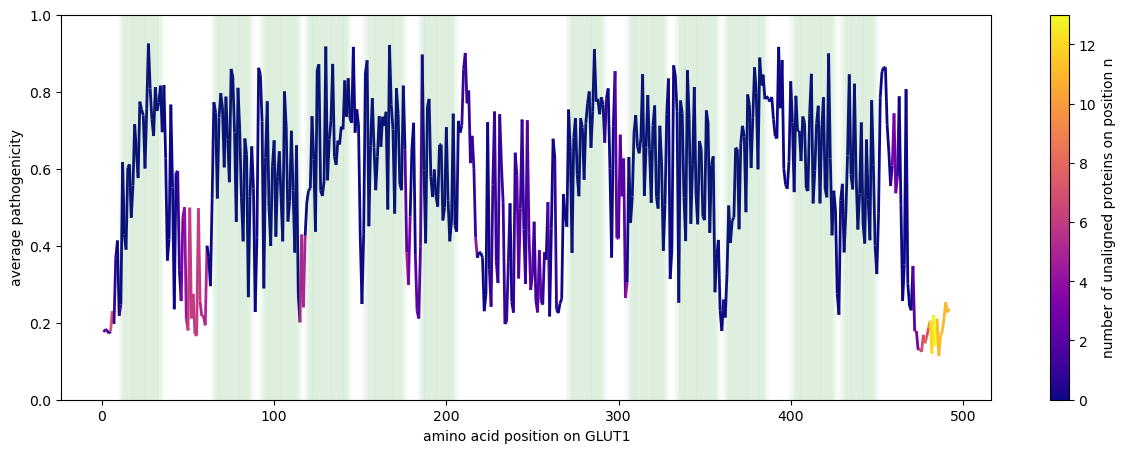

In [31]:
x = pato_align['GLUT1']
y = pato_align['avg_p']
missing = pato_align['missing'][:-1]

fig, ax = plt.subplots(figsize=(15, 5))
line = colored_line_between_pts(x, y, missing, ax, linewidth=2, cmap="plasma")
fig.colorbar(line, ax=ax, label="number of unaligned proteins on position n")
#ax.set_xlim(x.min(), x.max())


intracellurar = pato_align[pato_align['topology']== 'I'].index 
membrane = pato_align[pato_align['topology']== 'M'].index
extracellular = pato_align[pato_align['topology']== 'O'].index

plt.xlabel('amino acid position on GLUT1')
plt.ylabel('average pathogenicity')
#for x in zeros:
#    ax.axvline(pato_align.index[x], color='y',linewidth=5,alpha=0.03)
for x in membrane:
     ax.axvline(pato_align.index[x], color='g',linewidth=5,alpha=0.03)
#for x in neg_1:
#     ax.axvline(pato_align.index[x], color='r',linewidth=5,alpha=0.03)
plt.savefig(Path.cwd() / 'results/pathogenicity_alignment_GLUT1.tiff',format='tiff', dpi=300)
plt.show()